# Impact of Test Preparation on Students’ Math Performance: A Two-Sample T-Test with Data Visualization

# All Libraries


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
df = pd.read_csv('/content/drive/MyDrive/sumulation lab/project/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# column name
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# math score (completed vs none)

group_completed = df[df['test_preparation_course'] == 'completed']['math_score']
group_none = df[df['test_preparation_course'] == 'none']['math_score']

print("Group Sizes:")
print("Completed:", len(group_completed))
print("None:", len(group_none))


Group Sizes:
Completed: 358
None: 642


In [ ]:
# Test Variance Equality (Levene's Test)
# if p-value > 0.05 then pooled else weltch

levene_stat, levene_p = stats.levene(group_completed, group_none)
print("Levene's Test p-value:", levene_p)


Levene's Test p-value: 0.4655125071689348


# Two-Sample t-Test

In [ ]:
t_statistic, p_value = stats.ttest_ind(group_completed, group_none, equal_var=True)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 5.704616417349102
P-value: 1.5359134607147415e-08


In [ ]:
# mean difference
mean_diff = np.mean(group_completed) - np.mean(group_none)

# sample sizes
n1, n2 = len(group_completed), len(group_none)

# sample variances
s1_sq = np.var(group_completed, ddof=1)
s2_sq = np.var(group_none, ddof=1)

# pooled variance
sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)

# standard error
std_err = np.sqrt(sp_sq * (1/n1 + 1/n2))

# degrees of freedom (renamed as requested)
degree_of_freedom = n1 + n2 - 2

# 95% confidence interval
ci = stats.t.interval(0.95, degree_of_freedom, loc=mean_diff, scale=std_err)


In [ ]:
# Display Results

print(f"Mean (Completed): {np.mean(group_completed):.2f}")
print(f"Mean (None): {np.mean(group_none):.2f}")
print(f"T-Statistic: {t_statistic:.2f}")
print(f"Degree of Freedom: {degree_of_freedom}")
print(f"P-Value: {p_value:.8f}")
print(f"95% Confidence Interval: [{ci[0]:.2f}, {ci[1]:.2f}]")


Mean (Completed): 69.70
Mean (None): 64.08
T-Statistic: 5.70
Degree of Freedom: 998
P-Value: 0.00000002
95% Confidence Interval: [3.69, 7.55]


In [ ]:
# Conclusion

alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis. The means of the two samples are significantly different.")
else:
    print("Fail to reject the null hypothesis. The means of the two samples are not significantly different.")

Reject the null hypothesis. The means of the two samples are significantly different.


# Visualization

In [ ]:
import warnings
warnings.filterwarnings("ignore")


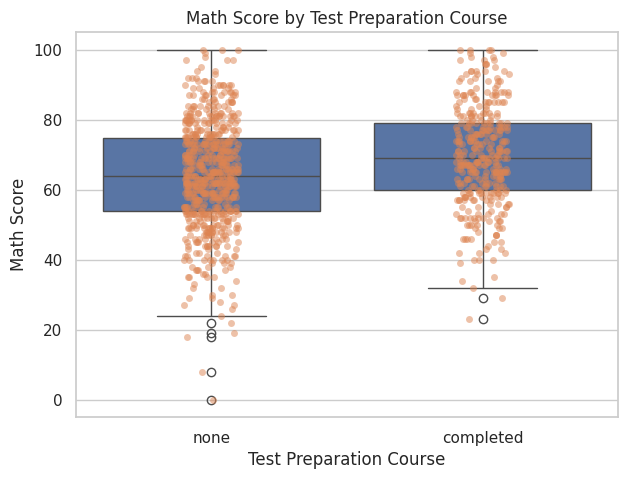

In [ ]:
# @title
# What this shows:
# - Side-by-side boxplots of Math Score for "completed" vs "none" test prep
# - Individual data points (strip) to reveal distribution and outliers

plt.figure(figsize=(7,5))
sns.boxplot(x='test_preparation_course', y='math_score', data=df)
sns.stripplot(x='test_preparation_course', y='math_score', data=df, alpha=0.5)
plt.title('Math Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.show()


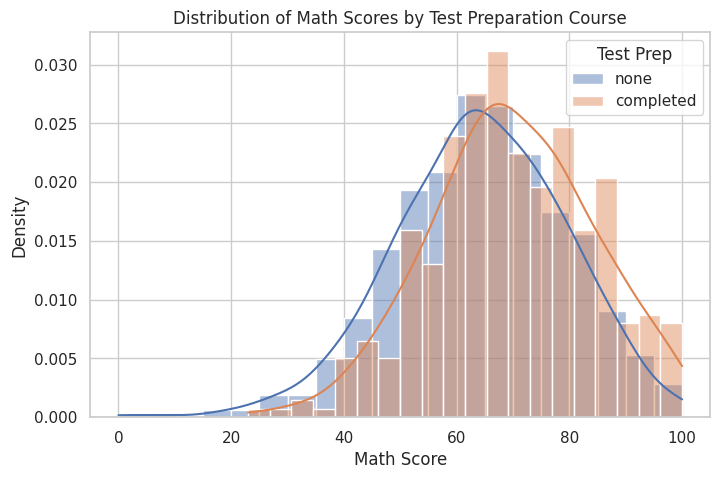

In [ ]:
# @title
# What this shows:
# - Overlaid histograms + density curves to compare the full distributions

plt.figure(figsize=(8,5))
for group in ['none', 'completed']:
    subset = df[df['test_preparation_course'] == group]['math_score']
    sns.histplot(subset, kde=True, bins=20, stat='density', label=group, alpha=0.45)

plt.legend(title='Test Prep')
plt.title('Distribution of Math Scores by Test Preparation Course')
plt.xlabel('Math Score')
plt.ylabel('Density')
plt.show()


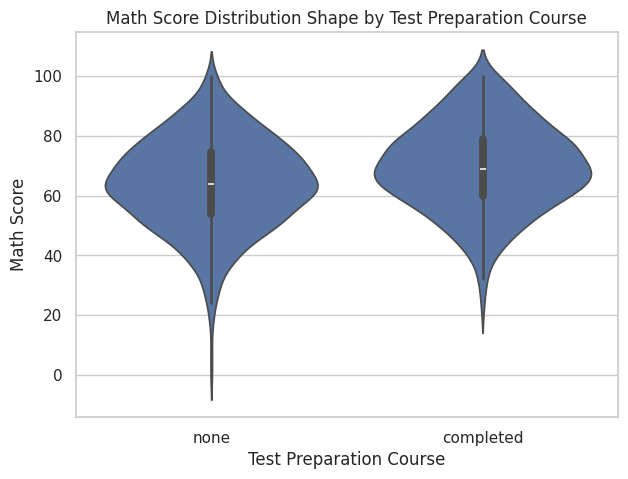

In [ ]:
# @title
# What this shows:
# - Violin (density shape) with an inner box for medians/IQR

plt.figure(figsize=(7,5))
sns.violinplot(x='test_preparation_course', y='math_score', data=df, inner='box')
plt.title('Math Score Distribution Shape by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.show()


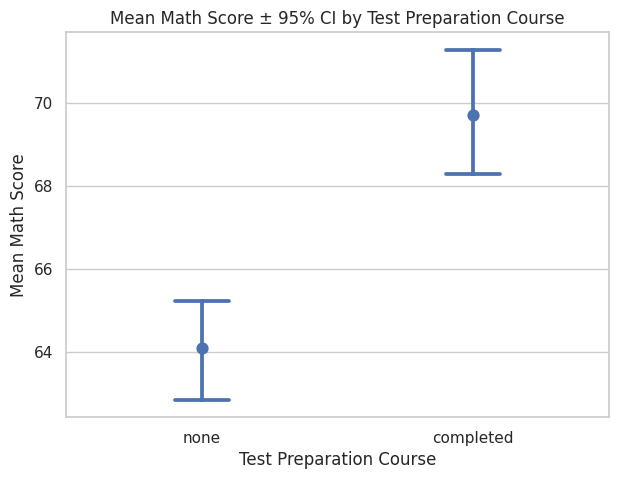

In [ ]:
# @title
# What this shows:
# - Group means with 95% confidence intervals (great summary visual)

plt.figure(figsize=(7,5))
sns.pointplot(x='test_preparation_course', y='math_score', data=df, ci=95, join=False, capsize=0.2)
plt.title('Mean Math Score ± 95% CI by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Mean Math Score')
plt.show()


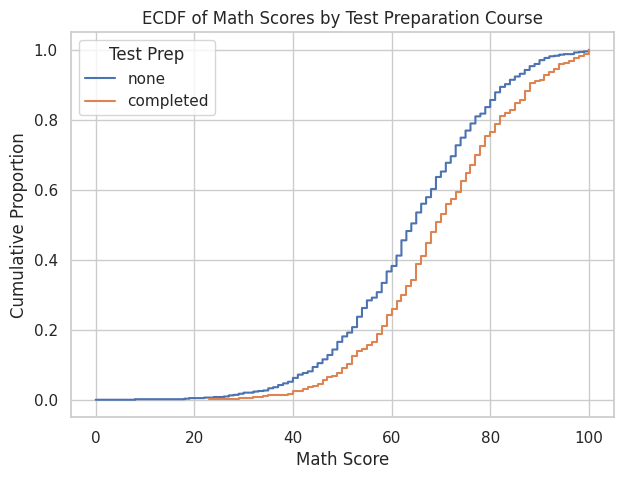

In [ ]:
# @title
# What this shows:
# - Empirical CDFs for both groups; a right-shifted curve indicates higher scores

plt.figure(figsize=(7,5))
for group in ['none', 'completed']:
    subset = df[df['test_preparation_course'] == group]['math_score'].sort_values()
    y = (range(1, len(subset)+1))
    plt.step(subset, [v/len(subset) for v in y], where='post', label=group)

plt.legend(title='Test Prep')
plt.title('ECDF of Math Scores by Test Preparation Course')
plt.xlabel('Math Score')
plt.ylabel('Cumulative Proportion')
plt.show()


Text(0.5, 0.98, 'Math Score by Test Prep, Faceted by Gender')

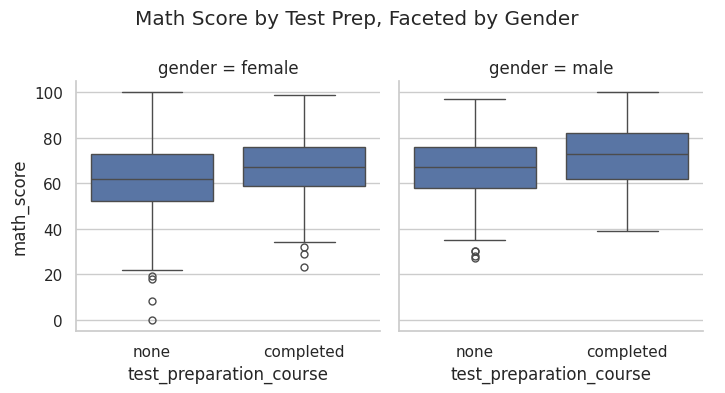

In [ ]:
# @title
# What this shows:
# - Whether the prep effect looks similar across genders

g = sns.catplot(
    data=df, x='test_preparation_course', y='math_score',
    col='gender', kind='box', height=4, aspect=0.9
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Math Score by Test Prep, Faceted by Gender')


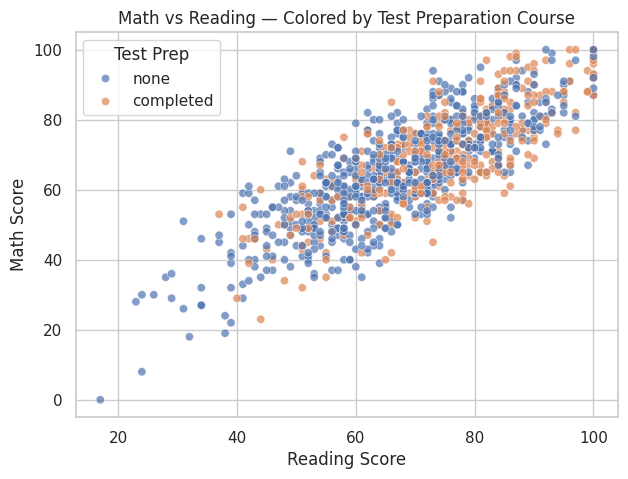

In [ ]:
# @title
# What this shows:
# - Relationship between Math and Reading scores, colored by prep status

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df, x='reading_score', y='math_score',
    hue='test_preparation_course', alpha=0.7
)
plt.title('Math vs Reading — Colored by Test Preparation Course')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.legend(title='Test Prep')
plt.show()


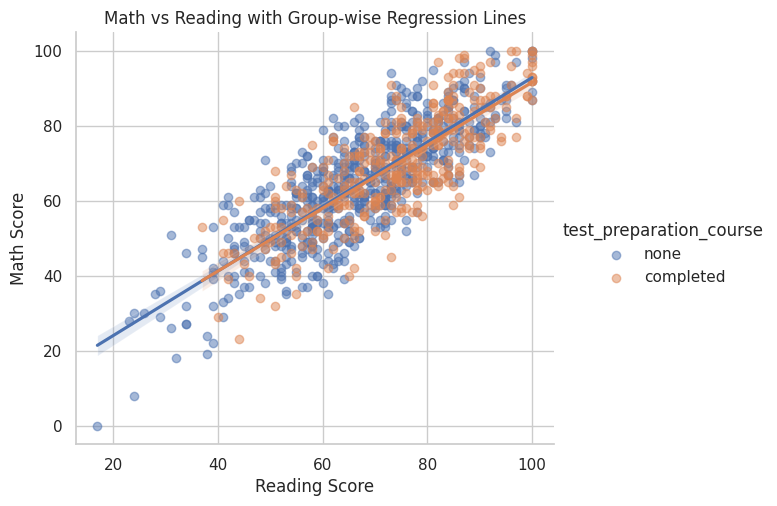

In [ ]:
# @title
# What this shows:
# - Best-fit lines for each group to see trend differences in Math vs Reading

sns.lmplot(
    data=df, x='reading_score', y='math_score',
    hue='test_preparation_course', height=5, aspect=1.2, scatter_kws={'alpha':0.5}
)
plt.title('Math vs Reading with Group-wise Regression Lines')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.show()


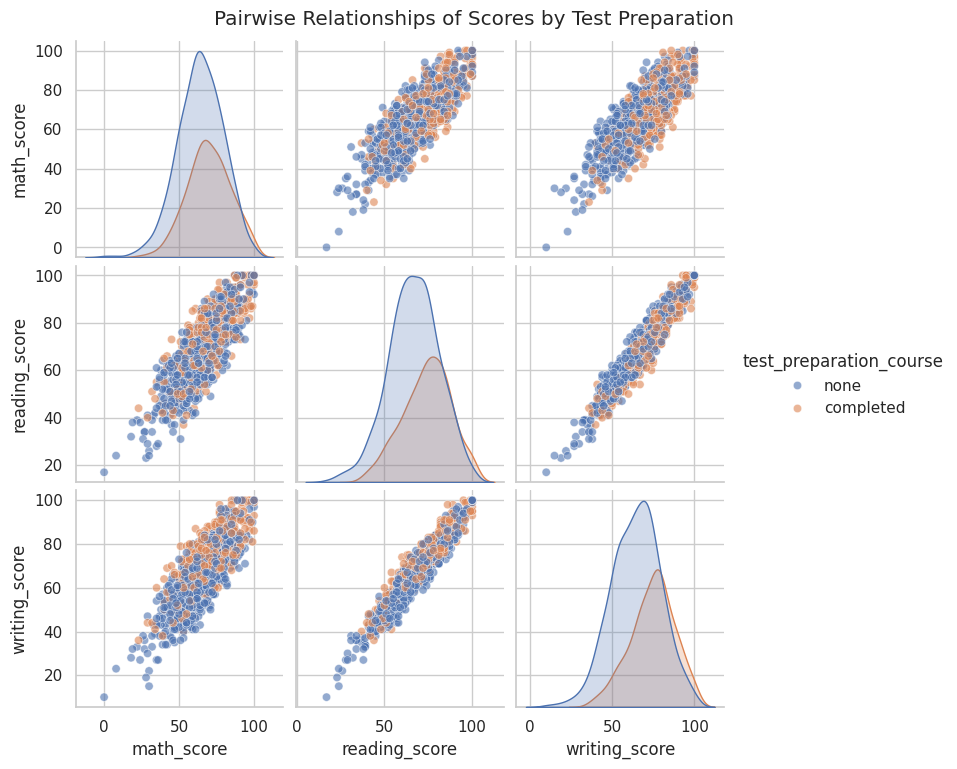

In [ ]:
# @title
# What this shows:
# - Pairwise relationships among Math, Reading, Writing, colored by prep
# - Great for spotting overall shifts and correlations

sns.pairplot(
    df[['math_score','reading_score','writing_score','test_preparation_course']],
    hue='test_preparation_course', plot_kws={'alpha':0.6}, diag_kind='kde'
)
plt.suptitle('Pairwise Relationships of Scores by Test Preparation', y=1.02)
plt.show()


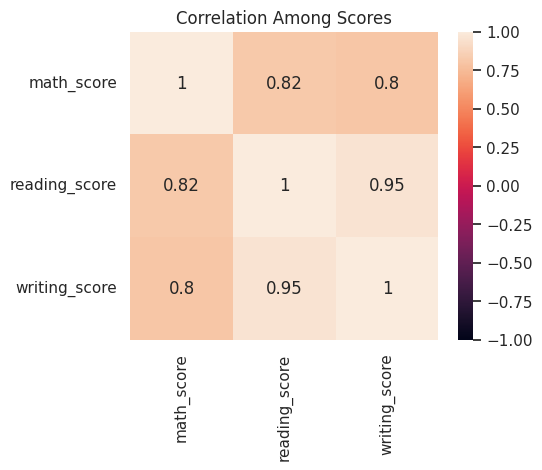

In [ ]:
# @title
# What this shows:
# - Correlations among Math, Reading, Writing (single-number summary)

plt.figure(figsize=(5,4))
corr = df[['math_score','reading_score','writing_score']].corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, square=True)
plt.title('Correlation Among Scores')
plt.show()


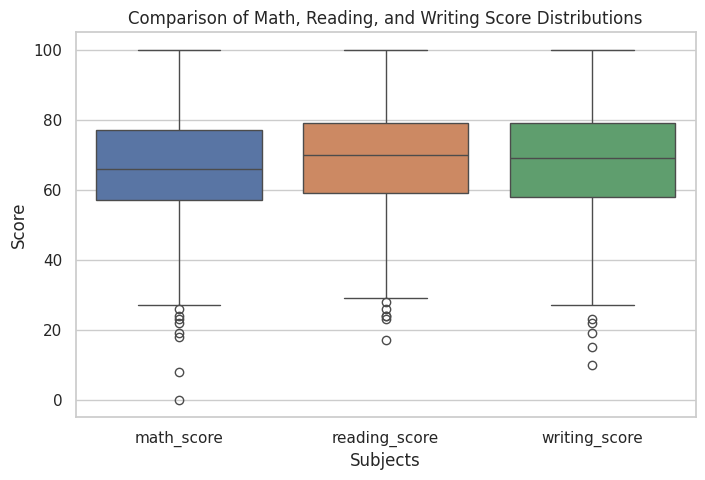

In [ ]:
# @title
# Purpose:
# 1) Compare score distributions for Math, Reading, and Writing directly.
# 2) Show which subject students generally score higher or lower in.
# 3) Helps identify whether performance patterns are consistent across subjects.

plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math_score', 'reading_score', 'writing_score']])
plt.title("Comparison of Math, Reading, and Writing Score Distributions")
plt.ylabel("Score")
plt.xlabel("Subjects")
plt.show()


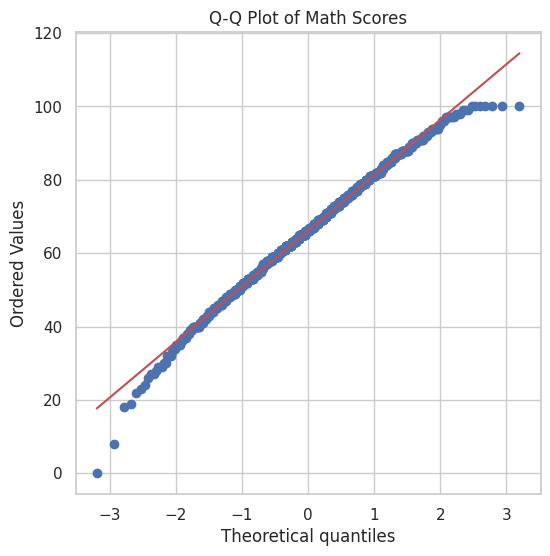

In [ ]:
# @title
# Purpose:
# 1) Check whether math scores follow a normal (bell curve) distribution.
# 2) If points follow the diagonal, distribution is approximately normal.
# 3) Helps confirm whether t-test assumptions are appropriate.

import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df['math_score'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Math Scores")
plt.show()
